# Table of Contents

1. [Session Overview: Supervised Learning Foundations](#session-02-supervised-learning-foundations)
2. [Train/Test Splitting](#train-test-splitting)
   - Basic Split Example
   - Time-Series vs. Standard Data (`shuffle`)
   - Stratified Splitting (`stratify`)
3. [Gradients & Gradient Descent](#gradients-gradient-descent)
   - What Is a Gradient?
   - Batch Gradient Descent (from scratch)
   - Stochastic Gradient Descent (SGD, from scratch)
   - Mini-Batch SGD (from scratch)
   - Comparing the Three Variants
   - `SGDRegressor` and Regression Metrics
4. [Overfitting vs. Underfitting](#overfitting-vs-underfitting)
   - Why They Happen
   - Visual Example with Polynomial Regression
   - Train/Test Error vs. Model Complexity
5. [Classification with KNN](#classification-with-knn)
6. [Outlier Detection](#outlier-detection)
   - Local Outlier Factor (LOF)
   - Mean ± Std Method
   - IQR Method
7. [Next Session Preview: SVM](#next-session-preview-svm)

---


## 📝 Session 02: Supervised Learning Foundations

In this session, we explore the core concepts of **Supervised Learning**, where the model learns from labeled datasets. We categorize these tasks into two primary types based on the nature of the target variables and their associated mathematical objectives:

To understand Machine Learning, we must distinguish between the **Task**, the **Model**, and the **Optimization Method**. Misinterpreting these can lead to fundamental errors in algorithm selection and implementation.

---
### 💡 Core Difference
While **Regression** models output a scalar value to map a relationship, **Classification** models aim to maximize the probability of the correct class, usually mapping the output through a function like *Softmax* for multi-class problems.

## 1. The Hierarchy of Learning

| Layer | Definition | Examples |
| :--- | :--- | :--- |
| **Task (The Goal)** | The nature of the problem we aim to solve. | Classification, Regression |
| **Model (The Architecture)** | The mathematical structure or algorithm used to represent the data. | Linear Regression, KNN, Neural Networks |
| **Optimizer (The Solver)** | The method used to find the best parameters for a given model. | Gradient Descent, Adam, Newton's Method |

---
The primary distinction between most ML tasks lies in the nature of the **Target Variable (Label/Output)**.


### 1.1 - Regression (Continuous Targets)
*   **Definition:** Predicting numerical values where the output space is continuous.
*   **Example:** Estimating house prices based on features like square footage, location, and year of construction.
*   **Mathematical Objective:** We typically minimize the difference between the predicted and actual values. The most common metric is **Mean Squared Error (MSE)**:
    $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### 1.2 - Classification (Discrete Targets)
*   **Definition:** Categorizing inputs into predefined, distinct classes.
*   **Example:** Image classification tasks, such as identifying specific animals (e.g., snake, leopard, rabbit) in a database.
*   **Mathematical Objective:** Instead of simple values, we often predict the *probability* of each class. The standard objective is to minimize the **Cross-Entropy Loss**:
    $$Loss = -\sum_{i} y_i \log(\hat{y}_i)$$




## 2. Comparative Analysis of Learning Paradigms

### Parametric vs. Non-Parametric Models

#### 2.1 - Parametric Models (e.g., Linear Regression, Neural Networks)
These models assume a specific functional form (a formula) for the mapping between input and output.
*   **Mechanism:** They learn a fixed set of parameters (weights $\theta$) during training.
*   **Learning Process:** They use **Iterative Optimization** (e.g., **Gradient Descent**) to minimize a loss function.
*   **Inference:** Extremely fast, as it only requires evaluating a formula.

#### 2.2 - Non-Parametric / Lazy Models (e.g., K-Nearest Neighbors - KNN)
These models do not make strong assumptions about the underlying function.
*   **Mechanism:** They do not learn a global formula; instead, they store the training data.
*   **Learning Process:** There is no explicit "training" phase (hence, **Lazy Learning**).
*   **Inference:** Computationally expensive at inference time, as it requires searching the entire dataset to find neighbors.

---

### 💡 Summary Table for Quick Reference

| Concept | Type | Label Nature | Learning Style |
| :--- | :--- | :--- | :--- |
| **Classification** | Task | **Discrete** (Categories) | N/A |
| **Regression** | Task | **Continuous** (Numbers) | N/A |
| **Linear Regression** | Model | Continuous | Parametric (Iterative) |
| **KNN** | Model | Both (Discrete/Continuous) | Non-Parametric (Lazy) |
| **Gradient Descent** | Optimizer | N/A | Iterative Solver |



## 1.Train/Test Splitting

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

> **⚠️ Important — Strict Separation of Training and Testing Sets**
>
> To ensure the model's ability to generalize to unseen data, it is imperative that the test dataset remains entirely independent of the training process. Any overlap between these sets **leads to data leakage**, resulting in overly optimistic performance metrics and a failure to evaluate true predictive power.
>
> We use `train_test_split` from the `sklearn` library.

In [2]:
X = np.array([1,2,3,4,5,6,7,8,9,10])#.reshape(-1,1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [3]:
print(X.shape)    #important to understand the problem

(10,)


In [4]:
np.unique(y,return_counts=True)   # return_counts: see all class in dataset

(array([0, 1]), array([5, 5]))

In [5]:
# NOTE: random_state should be a fixed integer (e.g. 42), not True/False.
# Passing True works only by accident (Python treats True as 1), and doesn't
# clearly communicate "this is a reproducibility seed" to someone reading the code.
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8, shuffle=True , random_state=42 ,stratify=y)

**Point-1 : Maintaining Temporal Integrity in Time-Series Data**

“When dealing with time-dependent data or datasets where observations are governed by temporal constraints, it is crucial to preserve their chronological order. **Randomly shuffling or intermingling** such data points violates their inherent temporal structure and **destroys the autocorrelation between consecutive observations**, leading to inaccurate model training and invalid evaluations.”

`shuffle=False`

**Point-2 : Ensuring Representative Test Sets via Stratification**

“To avoid a biased evaluation, it is critical that the test set represents the full distribution of the target labels. **A test set containing only a single class (e.g., a shape of (1, 1))** would fail to validate the model’s ability to generalize across all categories. Therefore, we implement `stratify=y` during the data split to ensure that the proportion of each class in both the training and testing sets remains consistent with the original dataset.”

In [6]:
print(X_train,X_test)

[9 5 2 1 7 6 8 3] [ 4 10]


In [7]:
print(y_train,y_test)

[1 0 0 0 1 1 1 0] [0 1]


In [8]:
from sklearn.datasets import load_digits

X,y = load_digits(return_X_y=True, as_frame=False)

print(X.shape)
print(np.unique(y,return_counts=True))

(1797, 64)
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([178, 182, 177, 183, 181, 182, 181, 179, 174, 180]))


(array([178., 182., 177., 183., 181., 182., 181., 179., 174., 180.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

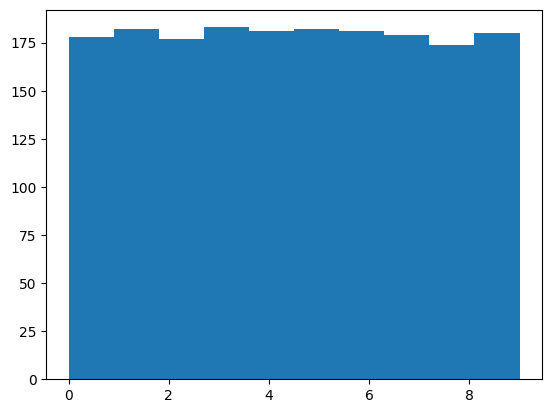

In [9]:
import matplotlib.pyplot as plt
plt.hist(y,bins=10)

**Fix applied below:** the original line reused `X_train` for both outputs of `train_test_split`
(`X_train, X_train, y_train, y_test = ...`), which silently discarded the test features —
`X_test` never actually existed. It has been corrected to `X_train, X_test, ...`.

(array([142., 145., 142., 146., 145., 146., 145., 143., 139., 144.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

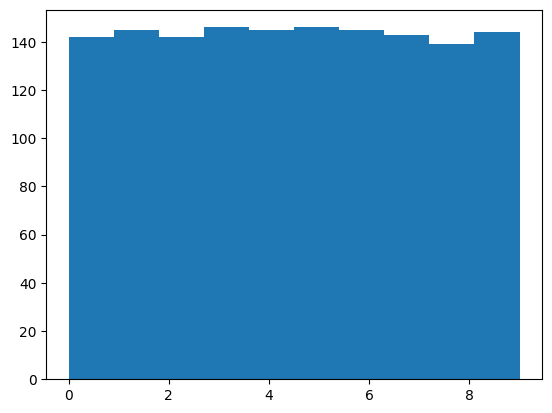

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8, stratify=y )
plt.hist(y_train,bins=10)
#plt.hist(y_test,bins=10)

In [11]:
X = np.array([1,2,3,4,5,6,7,8,9,10])#.reshape(-1,1)
y = np.array([122,130,143,144,151,158,160,163,167,170])

**Option A:** If your data is NOT Time-Series (Standard Regression)

 Since the target variable is continuous, we approach this as a Regression task.
 Given that the observations are independent and identically distributed (IID), we utilize shuffling during the train-test split to ensure the model is not biased by the input order.

**Option B:** If your data IS Time-Series (Time-Series Regression)

The task is a Regression problem involving continuous target variables. However, due to the temporal dependency inherent in the dataset, we set shuffle=False. This prevents data leakage (look-ahead bias), ensuring the model is evaluated on its ability to predict future values based solely on historical observations.

**The composition and sequencing** of training samples significantly influence both the convergence rate and the generalization accuracy of the model. Proper shuffling ensures that each mini-batch is a representative sample of the overall distribution, thereby mitigating gradient oscillations and facilitating stable optimization.

**Point-3 :** The primary objective of the optimization process is to achieve a monotonic decrease in the loss function, minimizing oscillations that may arise from high variance in gradients. We aim for stable convergence toward a global minimum, where the loss reaches a plateau, indicating that the optimizer has successfully captured the underlying patterns of the data and further training yields diminishing returns.

## 3.Gradients & Gradient Descent

We employ **Gradient Descent** as our **optimizer**; however, the efficacy of the optimization depends heavily on the step size **(learning rate)**. Properly **tuning this parameter is crucial to ensure the model converges** to the global minimum without overshooting or stagnating.

While we employ Gradient Descent as the optimizer, the primary challenge is determining the optimal step size to ensure convergence to the correct solution.


| Optimizer | Core Concept | Main Advantage | Key Hyperparameters |
| :--- | :--- | :--- | :--- |
| **SGD** | Simple Gradient | Minimal computational cost | $\eta$ (Learning Rate) |
| **Momentum** | Velocity/Inertia | Escapes local minima/dampens oscillations | $\eta$, $\mu$ (Momentum) |
| **RMSprop** | Adaptive Learning Rate | Handles non-stationary objectives | $\eta$, $\rho$ (Decay), $\epsilon$ |
| **Adam** | Momentum + RMSprop | Best balance of speed and stability | $\eta$, $\beta_1$, $\beta_2$, $\epsilon$ |



### What Is a Gradient?

A **gradient** is simply the vector of partial derivatives of a function with respect to each of its parameters. It tells you two things at any point:

- **Direction**: which way the function increases fastest.
- **Magnitude**: how steep the function is at that point.

If we want to *minimize* a function $J(\theta)$, we should move in the **opposite** direction of the gradient — that's the whole idea behind **Gradient Descent**:

$$\theta_{t+1} = \theta_t - \eta \cdot \nabla J(\theta_t)$$

where $\eta$ (eta) is the **learning rate** — how big a step we take each time.

#### A Minimal Example (Before Linear Regression)

Let's minimize the simplest possible function, $f(x) = (x - 3)^2$, whose minimum is obviously at $x = 3$.
Its derivative (1-D gradient) is $f'(x) = 2(x - 3)$. Watch how gradient descent finds $x=3$ on its own,
just by repeatedly stepping in the direction of $-f'(x)$:

Final x: 2.996286179882144  (true minimum is x = 3)


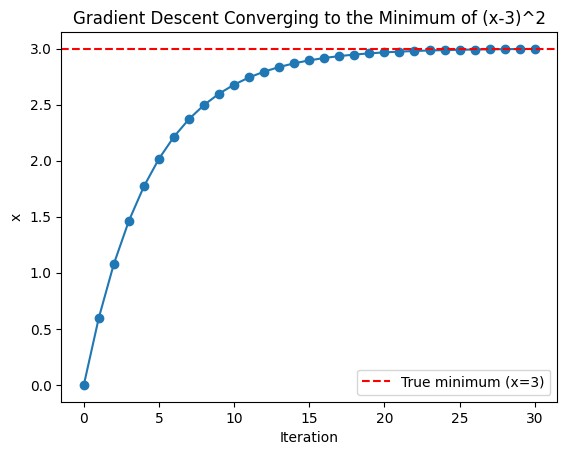

In [12]:
# Toy example: minimize f(x) = (x - 3)^2 using gradient descent
x = 0.0                # starting guess
learning_rate = 0.1
history = [x]

for step in range(30):
    gradient = 2 * (x - 3)      # derivative of (x-3)^2
    x = x - learning_rate * gradient
    history.append(x)

print("Final x:", x, " (true minimum is x = 3)")

plt.plot(history, marker='o')
plt.axhline(3, color='red', linestyle='--', label='True minimum (x=3)')
plt.xlabel('Iteration')
plt.ylabel('x')
plt.title('Gradient Descent Converging to the Minimum of (x-3)^2')
plt.legend()
plt.show()

Notice how $x$ moves quickly toward 3 at first (when the gradient/slope is large) and then
slows down as it gets close (when the gradient approaches zero). This exact same idea — take a step
opposite to the gradient, repeat — is what we now apply to a real regression problem below, where
instead of one parameter $x$ we have a parameter vector $\theta$ (intercept + slope), and instead of
$(x-3)^2$ we minimize the **Mean Squared Error** between predictions and true values:

$$J(\theta) = \frac{1}{n}\sum_{i=1}^{n}(X_i\theta - y_i)^2 \qquad \nabla J(\theta) = \frac{1}{n} X^T (X\theta - y)$$

### 3-1.Batch Gradient Descent

"Batch" means we use **all** training examples to compute the gradient at every single step. This gives
a smooth, stable descent, but can be slow if the dataset is large (every step scans the whole dataset).

In [13]:
X = np.array([1, 2, 3, 4, 5, 6, 7]).reshape(7, 1)
y = np.array([50, 55, 63, 72, 73, 76, 83]).reshape(7, 1)

n = len(X)

X_bias = np.c_[np.ones(n), X]

X_bias.shape

(7, 2)

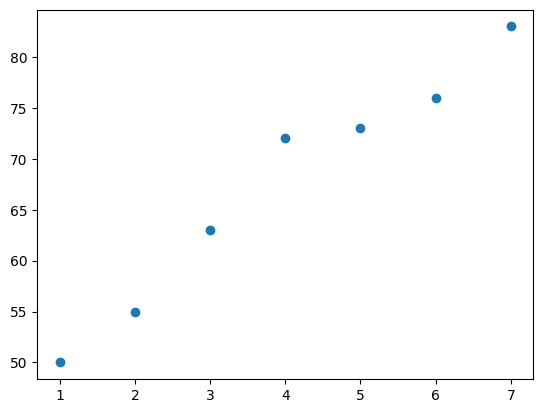

In [14]:
theta = np.array([[0],[0]], np.float64)

y_pred = X_bias @ theta

plt.scatter(X, y)
# plt.scatter(X, y_pred)
plt.show()

In [15]:
learning_rate = 0.01
max_iter = 1200
theta = np.array([[0],[0]], np.float64)

MSE: 4667.428571428572
MSE: 3065.4111591836736
MSE: 2060.195624427755
MSE: 1429.2610451678386
MSE: 1033.0554149488357
MSE: 784.0599379340671
MSE: 627.3879792668723
MSE: 528.617870948082
MSE: 466.1623652637769
MSE: 426.48320599987613
MSE: 401.08998973683435
MSE: 384.6580286509591
MSE: 373.8479850656154
MSE: 366.5656158557416
MSE: 361.49752779611936
MSE: 357.82003069533647
MSE: 355.0165472521937
MSE: 352.7631032861058
MSE: 350.8565139629142
MSE: 349.16934643095044
MSE: 347.6216750424238
MSE: 346.16336789395444
MSE: 344.7629779893684
MSE: 343.40077643206047
MSE: 342.06438325401683
MSE: 340.7460273293512
MSE: 339.4408279535695
MSE: 338.1457171513284
MSE: 336.8587638113134
MSE: 335.57874982339024
MSE: 334.3049042567213
MSE: 333.03673665185323
MSE: 331.7739324712422
MSE: 330.5162875318877
MSE: 329.2636668852438
MSE: 328.0159790290226
MSE: 326.7731597342572
MSE: 325.5351619024876
MSE: 324.3019492046841
MSE: 323.0734920918567
MSE: 321.8497652930418
MSE: 320.63074624609027
MSE: 319.416414113446

MSE: 101.11488224532332
MSE: 100.74372344480209
MSE: 100.37399027386434
MSE: 100.00567725663386
MSE: 99.63877893826714
MSE: 99.27328988487302
MSE: 98.90920468343181
MSE: 98.54651794171572
MSE: 98.18522428820833
MSE: 97.82531837202548
MSE: 97.4667948628357
MSE: 97.10964845078175
MSE: 96.75387384640143
MSE: 96.39946578054958
MSE: 96.0464190043199
MSE: 95.69472828896735
MSE: 95.34438842583056
MSE: 94.99539422625477
MSE: 94.64774052151486
MSE: 94.30142216273917
MSE: 93.9564340208326
MSE: 93.61277098640133
MSE: 93.27042796967676
MSE: 92.92939990044009
MSE: 92.58968172794748
MSE: 92.25126842085506
MSE: 91.91415496714458
MSE: 91.57833637404894
MSE: 91.2438076679783
MSE: 90.9105638944467
MSE: 90.57860011799838
MSE: 90.2479114221347
MSE: 89.9184929092416
MSE: 89.5903397005167
MSE: 89.26344693589716
MSE: 88.93780977398804
MSE: 88.61342339199007
MSE: 88.29028298562854
MSE: 87.9683837690819
MSE: 87.64772097491138
MSE: 87.32828985398986
MSE: 87.01008567543172
MSE: 86.69310372652284
MSE: 86.37733931

MSE: 28.663111162274465
MSE: 28.57024129924835
MSE: 28.477728151525714
MSE: 28.385570348954676
MSE: 28.293766526646404
MSE: 28.202315324954363
MSE: 28.11121538945457
MSE: 28.02046537092543
MSE: 27.930063925327737
MSE: 27.840009713784774
MSE: 27.750301402562382
MSE: 27.660937663049456
MSE: 27.57191717173799
MSE: 27.483238610203756
MSE: 27.394900665086436
MSE: 27.30690202807051
MSE: 27.219241395865616
MSE: 27.131917470187457
MSE: 27.044928957738474
MSE: 26.958274570188557
MSE: 26.87195302415628
MSE: 26.785963041189582
MSE: 26.70030334774706
MSE: 26.614972675178915
MSE: 26.529969759708354
MSE: 26.445293342412757
MSE: 26.36094216920501
MSE: 26.276914990814983
MSE: 26.193210562771156
MSE: 26.10982764538184
MSE: 26.02676500371719
MSE: 25.944021407590647
MSE: 25.861595631540958
MSE: 25.779486454813746
MSE: 25.697692661343684
MSE: 25.616213039736362
MSE: 25.535046383250315
MSE: 25.45419148977927
MSE: 25.37364716183416
MSE: 25.29341220652565
MSE: 25.21348543554626
MSE: 25.133865665152758
MSE: 2

MSE: 10.396427112791368
MSE: 10.373720007965678
MSE: 10.35110012165764
MSE: 10.328567118858926
MSE: 10.306120665847903
MSE: 10.283760430184858
MSE: 10.261486080706982
MSE: 10.239297287523376
MSE: 10.217193722010384
MSE: 10.1951750568065
MSE: 10.173240965807679
MSE: 10.15139112416243
MSE: 10.129625208267026
MSE: 10.107942895760715
MSE: 10.086343865520954
MSE: 10.06482779765856
MSE: 10.043394373513161
MSE: 10.02204327564831
MSE: 10.000774187846872
MSE: 9.979586795106242
MSE: 9.958480783633814
MSE: 9.937455840842247
MSE: 9.916511655344845
MSE: 9.895647916950955
MSE: 9.874864316661421
MSE: 9.854160546663877
MSE: 9.833536300328346
MSE: 9.812991272202536
MSE: 9.792525158007548
MSE: 9.772137654633081
MSE: 9.751828460133149
MSE: 9.73159727372155
MSE: 9.711443795767417
MSE: 9.69136772779074
MSE: 9.671368772458022
MSE: 9.651446633577768
MSE: 9.631601016096225
MSE: 9.611831626092897
MSE: 9.592138170776284
MSE: 9.57252035847951
MSE: 9.552977898655922
MSE: 9.533510501874982
MSE: 9.514117879817743
M

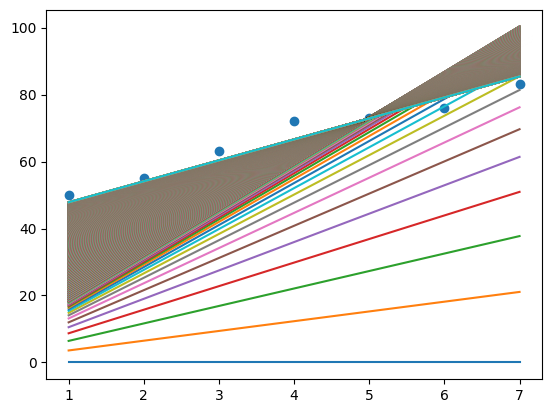

In [16]:
plt.scatter(X, y)

gd_cost_function = []

for iter in range(max_iter):
    y_pred = X_bias @ theta

    error = y_pred - y
    # print("Error:", error)

    gradient = (X_bias.T @ error) / n
    # print("Gradient:", gradient)

    theta -= gradient * learning_rate
    # print("Theta:", theta)

    mse = np.mean(np.square(y_pred - y))
    gd_cost_function.append(mse)
    print("MSE:", mse)

    plt.plot(X, y_pred, label=str(iter))

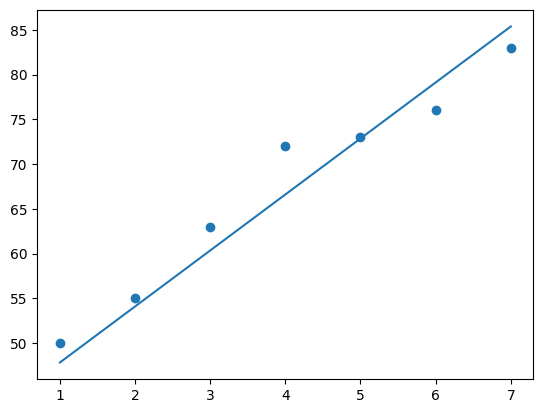

In [17]:
y_pred = X_bias @ theta

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.show()

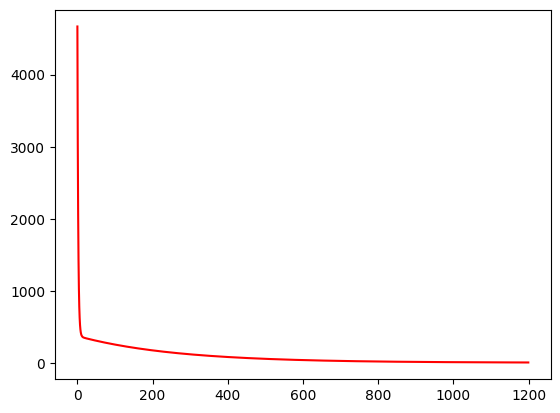

In [18]:
plt.plot(gd_cost_function, "r")

### 3-2.Stochastic Gradient Descent (SGD)

Instead of using the entire dataset to compute one gradient step, **SGD** updates $\theta$ using
**a single randomly chosen example** at a time. This makes each step much cheaper to compute and lets
the model start learning immediately, but the path to the minimum is noisier (it doesn't decrease
smoothly — it jitters) since each step is based on very limited information.

In [19]:
sgd_cost_function = []
learning_rate = 0.001
max_iter = 50
theta = np.array([[0],[0]], np.float64)

for iter in range(max_iter):
    indices = np.random.permutation(n)
    for i in range(n):
        index = indices[i]
        x_i = X_bias[index:index + 1]
        y_i = y[index:index + 1]
        y_pred = x_i @ theta

        error = y_pred - y_i

        gradient = x_i.T @ error

        theta -= gradient * learning_rate
        # print("Theta:", theta)

    mse = np.mean(np.square(y_pred - y))
    sgd_cost_function.append(mse)

### 3-3.Mini-Batch SGD

A middle ground between Batch GD and pure SGD: instead of 1 sample or the *whole* dataset, we use a
small **batch** of samples (here, `batch_size = 2`) per update. This is the approach most commonly used
in practice (including deep learning), because it balances computational efficiency with smoother,
more stable convergence than pure SGD.

In [20]:
minibatch_sgd_cost_function = []
learning_rate = 0.001
max_iter = 50
theta = np.array([[0],[0]], np.float64)
batch_size = 2

for iter in range(max_iter):
    indices = np.random.permutation(n)
    for i in range(0, n, batch_size):
        batch_indices = indices[i:i + batch_size]
        x_batch = X_bias[batch_indices]
        y_batch = y[batch_indices]
        h = np.dot(x_batch, theta)
        error = h - y_batch
        gradient = (1/batch_size) * np.dot(x_batch.T, error)
        theta -= learning_rate * gradient


    mse = np.mean(np.square(y_pred - y))
    minibatch_sgd_cost_function.append(mse)

### Comparing the Three Variants

Below, all three cost curves are plotted together. Expect to see:
- **Batch GD**: smooth, monotonically decreasing curve.
- **SGD**: noisier curve, more oscillation, but often converges in fewer *epochs*.
- **Mini-batch SGD**: somewhere in between — less noisy than pure SGD, cheaper per step than batch GD.

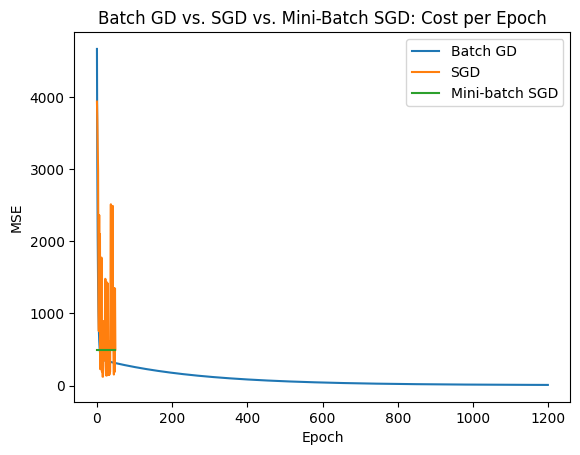

In [21]:
plt.plot(gd_cost_function, label='Batch GD')
plt.plot(sgd_cost_function, label='SGD')
plt.plot(minibatch_sgd_cost_function, label='Mini-batch SGD')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Batch GD vs. SGD vs. Mini-Batch SGD: Cost per Epoch')
plt.legend()
plt.show()

### `SGDRegressor` and Early Stopping

Scikit-learn's built-in `SGDRegressor` can stop training automatically once improvement becomes
negligible. Two parameters control this:
- `tol`: the minimum improvement in loss required to keep going.
- `n_iter_no_change`: how many consecutive epochs with no improvement (smaller than `tol`) are allowed
  before training stops early.

In [22]:
tol = 0.1  # convergence threshold used by SGDRegressor below

In [23]:
from sklearn.linear_model import SGDRegressor

SGDRegressor(
    tol=0.1,
    n_iter_no_change=5
)

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.1
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


### Regression Evaluation Metrics

- **MSE (Mean Squared Error)**: average of squared errors; penalizes large errors heavily.
- **MAE (Mean Absolute Error)**: average of absolute errors; more robust to outliers than MSE.
- **RMSE (Root Mean Squared Error)**: square root of MSE; back in the same units as the target variable,
  which makes it easier to interpret.

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

#mean_absolute_error(y, y_pred)

**Point-4 :** Data splitting strategy: It is crucial to maintain a representative distribution of all time-series event types within the training set. This ensures the model is exposed to the full range of patterns during the learning process, preventing performance issues on unseen event types during inference.

## 4.Overfitting vs. Underfitting

When we train a model, we care about how well it performs on **new, unseen data** — not just the data
it was trained on. Two common failure modes get in the way of this:

### Underfitting (High Bias)
The model is **too simple** to capture the real pattern in the data. It performs poorly on *both* the
training set and the test set.

**Why it happens:**
- The model has too little capacity for the problem (e.g., fitting a straight line to clearly curved data).
- Too few relevant features are used.
- Training was stopped too early, or the learning rate was too small to actually learn the pattern.
- Excessive regularization forces the model to stay too simple.

### Overfitting (High Variance)
The model is **too complex** relative to the amount/quality of training data. It performs *very well*
on the training set but *poorly* on the test set, because it has started memorizing noise and
peculiarities of the training examples instead of the general pattern.

**Why it happens:**
- The model has far more capacity (parameters) than the data can justify.
- The training set is small or noisy, so the model can "memorize" it instead of generalizing.
- The model was trained for too many epochs without any regularization or early stopping.
- Too many irrelevant/noisy features relative to the number of training examples.

### The Goal: A Good Fit
Between these two extremes is a model complexity that captures the true underlying pattern without
chasing noise. Let's see all three cases visually.

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Synthetic data: a noisy sine wave. The true underlying pattern is non-linear,
# so a straight line will underfit it, while a very high-degree polynomial will overfit it.
rng = np.random.RandomState(0)
X_of = np.sort(rng.rand(30, 1) * 2 * np.pi, axis=0)
y_of = np.sin(X_of).ravel() + rng.normal(0, 0.2, size=X_of.shape[0])

X_true = np.linspace(0, 2 * np.pi, 200).reshape(-1, 1)
y_true = np.sin(X_true).ravel()

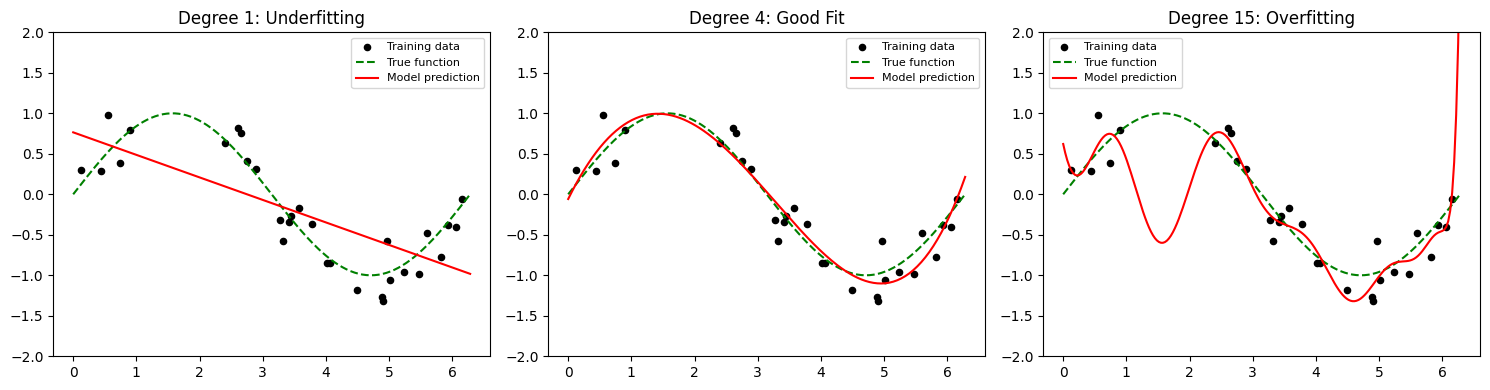

In [26]:
degrees = [1, 4, 15]          # underfit, good fit, overfit
titles = ['Degree 1: Underfitting', 'Degree 4: Good Fit', 'Degree 15: Overfitting']

plt.figure(figsize=(15, 4))
for i, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X_of)

    model_of = LinearRegression()
    model_of.fit(X_poly, y_of)

    y_plot = model_of.predict(poly.transform(X_true))

    plt.subplot(1, 3, i + 1)
    plt.scatter(X_of, y_of, color='black', s=20, label='Training data')
    plt.plot(X_true, y_true, color='green', linestyle='--', label='True function')
    plt.plot(X_true, y_plot, color='red', label='Model prediction')
    plt.ylim(-2, 2)
    plt.title(titles[i])
    plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

Notice the pattern above:
- **Degree 1** (straight line) can't bend to follow the sine wave — it misses the pattern everywhere. This is underfitting.
- **Degree 4** follows the true sine curve closely without chasing every noisy point. This is a good fit.
- **Degree 15** wiggles wildly to pass as close as possible to every single training point, including the noise. This is overfitting — it would predict poorly on any new point.

### Train/Test Error vs. Model Complexity

A very common way to *detect* overfitting/underfitting in practice is to plot training error and test
error as model complexity increases. Typically:
- **Training error** keeps decreasing as complexity increases (the model can always fit the training
  data better with more capacity).
- **Test error** decreases at first (as underfitting is resolved), reaches a minimum, then increases
  again (as overfitting sets in).

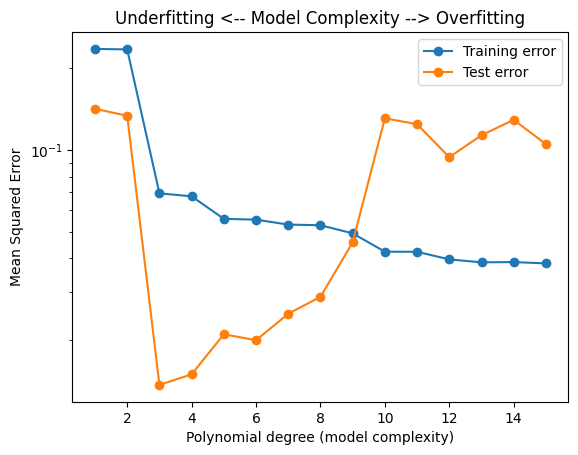

In [27]:
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(
    X_of, y_of, test_size=0.3, random_state=42
)

degree_range = range(1, 16)
train_errors, test_errors = [], []

for degree in degree_range:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_of)
    X_test_poly = poly.transform(X_test_of)

    model_of = LinearRegression()
    model_of.fit(X_train_poly, y_train_of)

    train_errors.append(mean_squared_error(y_train_of, model_of.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test_of, model_of.predict(X_test_poly)))

plt.plot(list(degree_range), train_errors, marker='o', label='Training error')
plt.plot(list(degree_range), test_errors, marker='o', label='Test error')
plt.xlabel('Polynomial degree (model complexity)')
plt.ylabel('Mean Squared Error')
plt.yscale('log')
plt.title('Underfitting <-- Model Complexity --> Overfitting')
plt.legend()
plt.show()

On the left side of this plot (low degree), **both** curves are high — that's underfitting: the model
is too simple to do well on train *or* test data. On the right side (high degree), the training error
keeps dropping while the test error rises back up — that's overfitting: the model does great on data it
has memorized but generalizes poorly. The best degree is wherever the **test error is lowest**, not
wherever the training error is lowest.

**Common ways to fight overfitting:** get more training data, use regularization (L1/L2), reduce model
complexity, use early stopping, or use cross-validation to pick hyperparameters.
**Common ways to fight underfitting:** increase model complexity, add more/better features, train longer,
or reduce regularization strength.

## 5.Classification with KNN

# Classification

In [28]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt 
import numpy as np

In [29]:
X,y = make_blobs(n_samples=150 , n_features=2 , centers=3)

In [30]:
# approach 1: KNN
# Recommender systems are a good practical use case for KNN
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances
#  weights: 'uniform' (all neighbors count equally) or 'distance' (closer neighbors count more)
#  algorithm: 'brute' (good for small data), 'kd_tree', 'auto', or 'ball_tree'

from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',      # or 'distance'
    algorithm='auto',
)

model.fit(X,y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


array(['blue'], dtype='<U6')

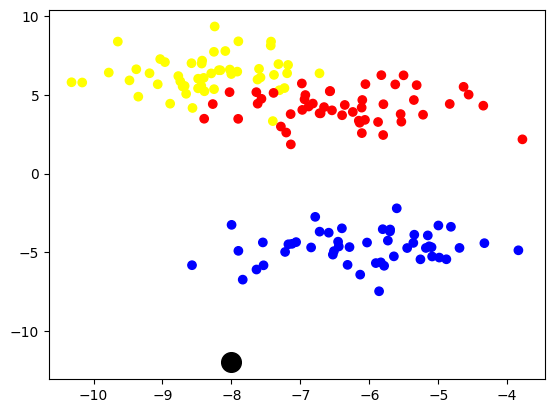

In [31]:
colors = np.array(['blue','yellow','red'])
plt.scatter(X[:,0], X[:,1], c=colors[y])  # we have discrete (categorical) results

point = np.array([[-8,-12]])  # change this point to test different regions of the plot
plt.scatter(point[0,0], point[0,1], c="k" ,s=200)
#model.predict(point)
colors[model.predict(point)]

In [32]:
model.predict([[4,-6]])   # belong to which group?    

array([0])

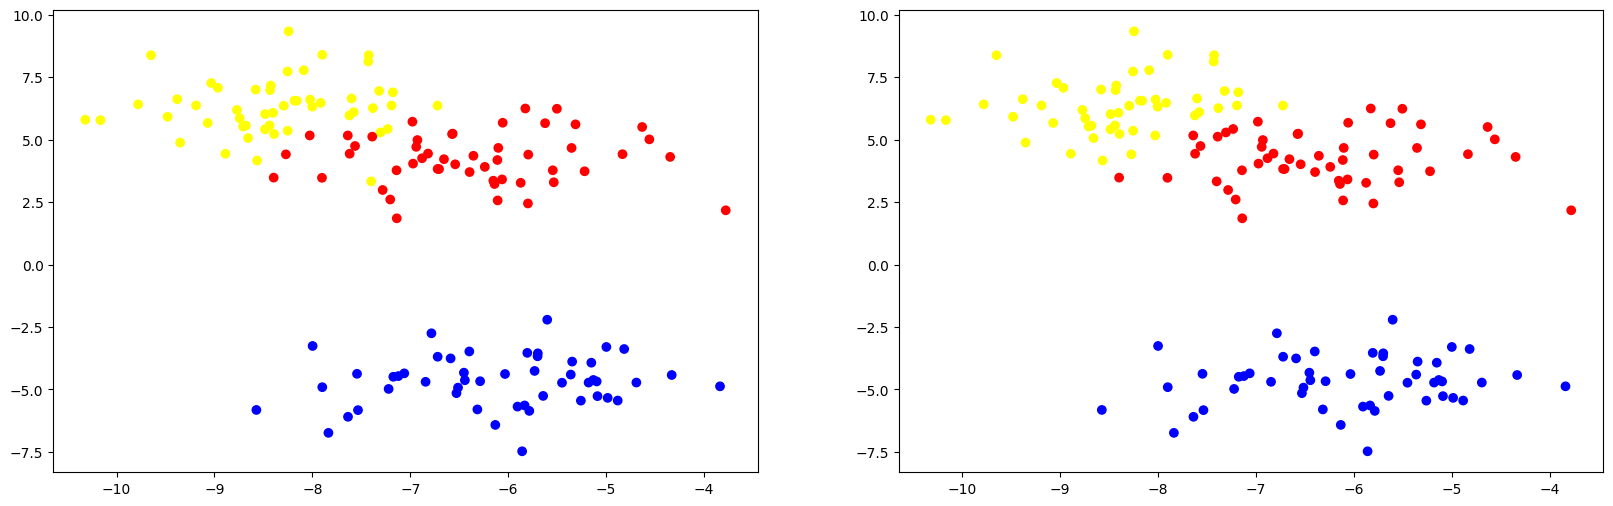

In [33]:
plt.figure(figsize=(20,6))
colors = np.array(["blue", "yellow", "red"])

plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1], c=colors[y])

model.fit(X,y)
y_pred = model.predict(X)

plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1], c=colors[y_pred])


## 6.Outlier Detection

**Outlier finding by KNN (Local Outlier Factor)**

In [34]:
# NOTE: LocalOutlierFactor must be imported explicitly — it was missing in the
# original notebook, which only worked because of leftover state from a previous run.
from sklearn.neighbors import LocalOutlierFactor

X = np.array([1,2,3,4,30,7,8,900]).reshape(-1,1)

lof = LocalOutlierFactor(n_neighbors=4)
lof.fit_predict(X)  # detect outliers: -1 means outlier, 1 means inlier

array([ 1,  1,  1,  1, -1,  1,  1, -1])

In [35]:
outlier = lof.fit_predict(X)
X[outlier==-1]

array([[ 30],
       [900]])

In [36]:
np.where(outlier==-1)

(array([4, 7]),)

In [37]:
idx = np.where(outlier==-1)
idx

(array([4, 7]),)

In [38]:
import pandas as pd

df = pd.DataFrame(np.c_[idx[0], X[idx]] , columns=["index", "value"])
df

,index,value
0,4,30
1,7,900


**Outlier finding by Mean and Standard Deviation**

In [39]:
mean = X.mean()
std = X.std()

upper_bond = mean + 2 * std
lower_bond = mean - 2 * std

outlier = X[(X > upper_bond) | (X < lower_bond)]
outlier

array([900])

**Outlier finding by IQR (Interquartile Range)**

In [40]:
Q1 = np.quantile(X, .25)
Q3 = np.quantile(X, .75)

IQR = Q3 - Q1

upper_bond = Q3 + 1.5 * IQR
lower_bond = Q1 - 1.5 * IQR

outlier = X[(X > upper_bond) | (X < lower_bond)]
outlier

array([ 30, 900])

## Next Session Preview: SVM

🚧 *To be continued in the next session.*

In [41]:
# approach 2: SVM (to be covered next session)